In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from utils.evaluation import  WassersteinDistance1D
from samplers.dpsgld import DPSGLD1D
from samplers.mysgld import MYSGLD1D
from tqdm import  tqdm

plt.rcParams['font.family'] = 'Times New Roman'

# Sampling in $\mathbb{R}$

We want to sample from $\pi(x)\propto e^{-U(x)}\mathbf{1}_{\mathcal{K}}(x)$, where $\mathcal{K}= [-R, R]$ (we take $R=1$). In this example, we use $U(x)=\frac{\mu}{2}x^2+\frac{1}{4}\beta x^4-bx$ with $\mu=1.0, \beta=0.5$, and $b=1$.

In [2]:
def global_potential(x, mu=1.0, beta=0.5, b=1.0):
    f = 0.5*mu*x**2 + 0.25*beta*x**4 - b*x
    return f

In [3]:
# pi on grid
def true_distn_pi_on_grid(mu, beta, b, R, n_grid=40001):
    x = np.linspace(-R, R, n_grid)
    logp = -global_potential(x, mu, beta, b)
    logp -= logp.max()                          # Stabilize
    p_unn = np.exp(logp)
    dx = x[1] - x[0]
    Z = p_unn.sum() * dx
    pdf = p_unn / Z
    return x, pdf

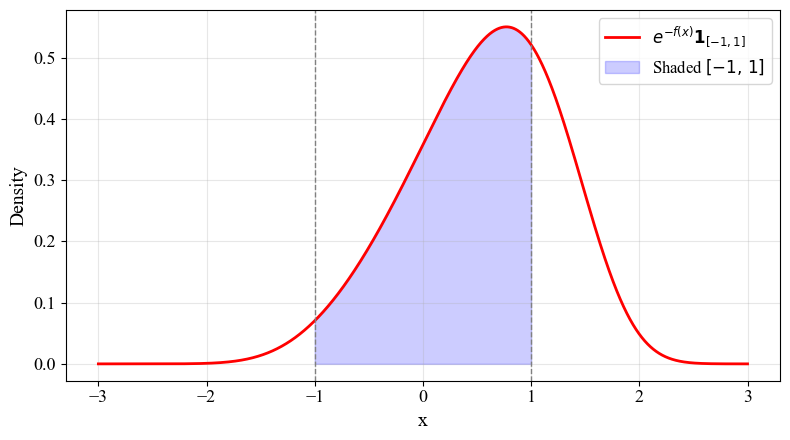

In [4]:
# Parameters 
mu, beta, b = 1.0, 0.5, 1.0
R, n_grid = 1.0, 40001
shade_a, shade_b = -R, R

x, pdf = true_distn_pi_on_grid(mu, beta, b, R, n_grid=40001)
xx = np.linspace(-3,3, n_grid)
expU_unn = np.exp(-global_potential(xx, mu, beta, b))
dx = xx[1] - xx[0]
Z_exp = expU_unn.sum() * dx
expU_pdf = expU_unn / Z_exp   # normalized on [-1,1]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(xx, expU_pdf, color='red', lw=2, label=r'$e^{-f(x)}\mathbf{1}_{[-1,1]}$')
ax.fill_between(xx, expU_pdf, 0.0, where=(xx>=shade_a) & (xx<=shade_b),
                color='blue', alpha=0.2, label=r'Shaded $[-1,\,1]$')
ax.axvline(-1, color='gray', ls='--', lw=1)
ax.axvline( 1, color='gray', ls='--', lw=1)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=13)
plt.tight_layout()
plt.savefig('images/target.png')
plt.show()


However, instead of $U(x)$, we use a proximal function in the potential:

$$\pi^{\gamma}(x)\propto e^{-U^{\gamma}(x)}$$

where, $U^{\gamma}(x)=\frac{\mu}{2}x^2+\frac{1}{4}\beta x^4-bx+\frac{1}{2\gamma}(x-\Pi(x))^2$, and $\Pi(x)$ is the projection on to the box $\mathcal{K}=[-1,1]$.

Once we sample, we then compute the 2-Wasserstein distance in 1 dimension based on the definition by Panaretos et. al,

$$\mathcal{W}_2^2(\mu, \nu) = \int_0^1 (F^{-1}_{\mu}(u)-F^{-1}_{\nu}(u))^2 du\approx \frac1n\sum_{k=1}^n (Q(u_k)-x^{(k)}),\quad u_k=\frac{k-\frac12}{n}$$

where, $Q=F^{-1}$ is the true quantile of the target on $[-R, R]$, and $x^{(k)}$ are stored samples at the $k$th iteration.

### True target quantile function $Q(u)$ for $\pi(x)\propto e^{-f(x)}\mathbf{1}_{[-R, R]}$

In [5]:
def make_target_quantile(R, mu=1.0, beta=0.5, b=1.0, grid_size=200_001):
    """
    Returns a collable Q(u)=F^{-1}(u) for the truncated target on [-R, R].
    Uses a dense grid + stabilized exp + trapezoidal CDF + monotone inversion
    """
    x = np.linspace(-R, R, grid_size)
    f = 0.5 * mu * x**2 + 0.25 * beta * x**4 - b * x 
    # Stabilize exp(-f)
    logw = -f 
    logw -= logw.max()
    w = np.exp(logw)
    
    # Trapezoid cumulative integral to get unnormalized CDF
    dx = x[1] - x[0]
    cdf_unnormalized = np.cumsum((w[:-1] + w[1:]) * 0.5) * dx 
    cdf_unnormalized = np.concatenate(([0.0], cdf_unnormalized))
    
    Z = cdf_unnormalized[-1]
    if not np.isfinite(Z) or Z <= 0:
        raise RuntimeError("Normalization failed; check parameters/grid size.")
    
    cdf = cdf_unnormalized / Z 
    
    # Monotone inversion
    cdf = np.maximum.accumulate(cdf)
    cdf[0] = 0.0 
    cdf[-1] = 1.0
    
    def Q(u):
        u = np.asarray(u)
        u = np.clip(u, 0.0, 1.0)
        return np.interp(u, cdf, x)
    
    return Q

In [6]:
Q = make_target_quantile(R=R)

In [7]:
def density_from_samples(samples, grid, density=True):
    """
    Build a 1D density estimate on grid from samples using histogram.
    Returns density values on the grid.
    """ 
    samples = np.asarray(samples).reshape(-1)
    bins = len(grid) - 1
    hist, edges = np.histogram(
        samples, bins=bins, range=(grid[0], grid[-1]), density=density
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    pdf_grid = np.interp(grid, centers, hist, left=0.0, right=0.0)
    return pdf_grid

In [8]:
def tail_pool(chain2d, tail=50):
    """
    chain2d: shape (n_iters, N)
    Returns pooled samples from the last `tail` iterations: shape (tail*N,)
    """
    chain2d = np.asarray(chain2d)
    tail = min(tail, chain2d.shape[0])
    return chain2d[-tail:, :].reshape(-1)

In [9]:
def plot_target_vs_samples(
    xx, target_pdf, dpsgld_agent_chain, dpsgld_mean_chain, mysgld_chain,
    R=1.0, tail=50, figsize=(24, 8),
    savepath=None
):
    # Pooled samples from tail
    dpsgld_mean_chain = tail_pool(dpsgld_mean_chain, tail=tail)
    dpsgld_agent_chain = tail_pool(dpsgld_agent_chain, tail=tail)
    mysgld_chain = tail_pool(mysgld_chain, tail=tail)
    
    
    # density estimates on xx
    dpsgld_mean_pdf = density_from_samples(dpsgld_mean_chain, xx)
    dpsgld_agent_pdf = density_from_samples(dpsgld_agent_chain, xx)
    mysgld_pdf = density_from_samples(mysgld_chain, xx)
    
    
    fig, axes = plt.subplots(1,3, figsize=figsize, sharey=False)
    
    
    # DPSGLD mean
    axes[0].plot(xx, dpsgld_mean_pdf, lw=3, color='orange')
    axes[0].axvline(-R, color='gray', ls='--', lw=1)
    axes[0].axvline( R, color='gray', ls='--', lw=1)
    axes[0].set_title(f'DE-PSGLD (mean) density\n (pooled last {tail} iters)', fontsize=30)
    axes[0].set_xlabel('x', fontsize=30)
    axes[0].grid(alpha=0.25)
    axes[0].tick_params(axis="both", which="major", labelsize=30)
    
    # DPSGLD agent
    axes[1].plot(xx, dpsgld_agent_pdf, lw=3, color='green')
    axes[1].axvline(-R, color='gray', ls='--', lw=1)
    axes[1].axvline( R, color='gray', ls='--', lw=1)
    axes[1].set_title(f'DE-PSGLD agent density\n (pooled last {tail} iters)', fontsize=30)
    axes[1].set_xlabel('x', fontsize=30)
    axes[1].grid(alpha=0.25)
    axes[1].tick_params(axis="both", which="major", labelsize=30)
    
    # MYSGLD 
    axes[2].plot(xx, mysgld_pdf, lw=3, color='purple')
    axes[2].axvline(-R, color='gray', ls='--', lw=1)
    axes[2].axvline( R, color='gray', ls='--', lw=1)
    axes[2].set_title(f'PSGLD density\n (pooled last {tail} iters)', fontsize=30)
    axes[2].set_xlabel('x', fontsize=30)
    axes[2].grid(alpha=0.25)
    axes[2].tick_params(axis="both", which="major", labelsize=30)
    
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=300)
    plt.show()

Define the run and plot

In [10]:
def dpsgld_sampling_run(
    Q,
    n_agents=100,
    n_samples=100,
    n_iters=150,
    eta=5e-4,
    sigma_grad=0.5,
    gamma=1e-3,
    R=1.0,
    nets=("fcn", "cn", "sn", "fdn"),
    specific_net='fcn',
    seed=121,
    figsize=(32, 12),
    logy=False,
    w2distplot=True,
    tail=50
):
    if w2distplot:
        fig, axes = plt.subplots(2, 4, figsize=figsize, sharey=False)
        network_names = ["Fully Connected", "Circular", "Star", "Disconnected"]

        
        agent_ids = np.sort(random.sample(range(1, n_agents), 3))

        for j, (net, name) in enumerate(zip(nets, network_names)):
            ax_top = axes[0, j]
            ax_bot = axes[1, j]

            sampler = DPSGLD1D(
                n_agents=n_agents, n_samples=n_samples, n_iters=n_iters,
                eta=eta, gamma=gamma, sigma_grad=sigma_grad,
                net=net, R=R, seed=seed
            )
            history_all, X_mean_all = sampler.sample()

            my_sampler = MYSGLD1D(
                eta=eta, n_samples=n_samples, n_iters=n_iters,
                sigma_grad=sigma_grad, gamma=gamma,
                R=R, seed=seed
            )
            my_chain = my_sampler.sample()

            dist = WassersteinDistance1D(history_all=history_all, X_mean_all=X_mean_all)
            w2dis = dist.W2dist(Q)                         # list: n_agents agents + mean at the end
            w2_my = dist.W2distSingleChain(my_chain, Q)     # 1D array length n_iters

            # ---- Top row: selected agents + mean ----
            for i in agent_ids:
                ax_top.plot(w2dis[i], label=f"Agent {i}", linewidth=4, alpha=0.9)
            ax_top.plot(w2dis[-1], label="Mean", linewidth=4, alpha=0.9, color='red')

            ax_top.set_title(name, fontsize=30)
            ax_top.grid(True, alpha=0.25)
            ax_top.set_xlabel("Iteration", fontsize=30)
            ax_top.set_ylabel(r"$\mathcal{W}_2$", fontsize=30)
            if logy:
                ax_top.set_yscale("log")
            ax_top.legend(loc="best", fontsize=18)
            ax_top.tick_params(axis="both", which="major", labelsize=28)

            # ---- Bottom row: mean vs MY ----
            ax_bot.plot(w2dis[-1], label="Mean DE-PSGLD", linewidth=4, alpha=0.9, color='red')
            ax_bot.plot(w2_my, label="PSGLD", linewidth=4, alpha=0.9)

            ax_bot.grid(True, alpha=0.25)
            ax_bot.set_xlabel("Iteration", fontsize=24)
            ax_bot.set_ylabel(r"$\mathcal{W}_2$ Distance", fontsize=30)
            if logy:
                ax_bot.set_yscale("log")
            ax_bot.legend(loc="best", fontsize=28)
            ax_bot.tick_params(axis="both", which="major", labelsize=28)

        plt.tight_layout()
        plt.savefig("images/1dsampling.png")
        plt.show()
    
    # Density plot comparison for specific net
    dpsgld_sampler = DPSGLD1D(
            n_agents=n_agents, n_samples=n_samples, n_iters=n_iters,
            eta=eta, gamma=gamma, sigma_grad=sigma_grad,
            net=specific_net, R=R, seed=seed
        )
    history_all, X_mean_all = dpsgld_sampler.sample()
    dpsgld_agent_chain = history_all[:,0, 0, :]
    dpsgld_mean_chain = X_mean_all[:, 0, :]
    
    
    my_sampler = MYSGLD1D(
            eta=eta, n_samples=n_samples, n_iters=n_iters,
            sigma_grad=sigma_grad, gamma=gamma,
            R=R, seed=seed
        )
    my_chain = my_sampler.sample()
    
    plot_target_vs_samples(
        xx=xx,
        target_pdf=expU_pdf,
        dpsgld_agent_chain=dpsgld_agent_chain,
        dpsgld_mean_chain=dpsgld_mean_chain,
        mysgld_chain=my_chain,
        R=R,
        tail=tail,
        savepath='images/1dsampling_density_compare.png'
    )

100%|██████████| 300/300 [00:00<00:00, 2939.77it/s]


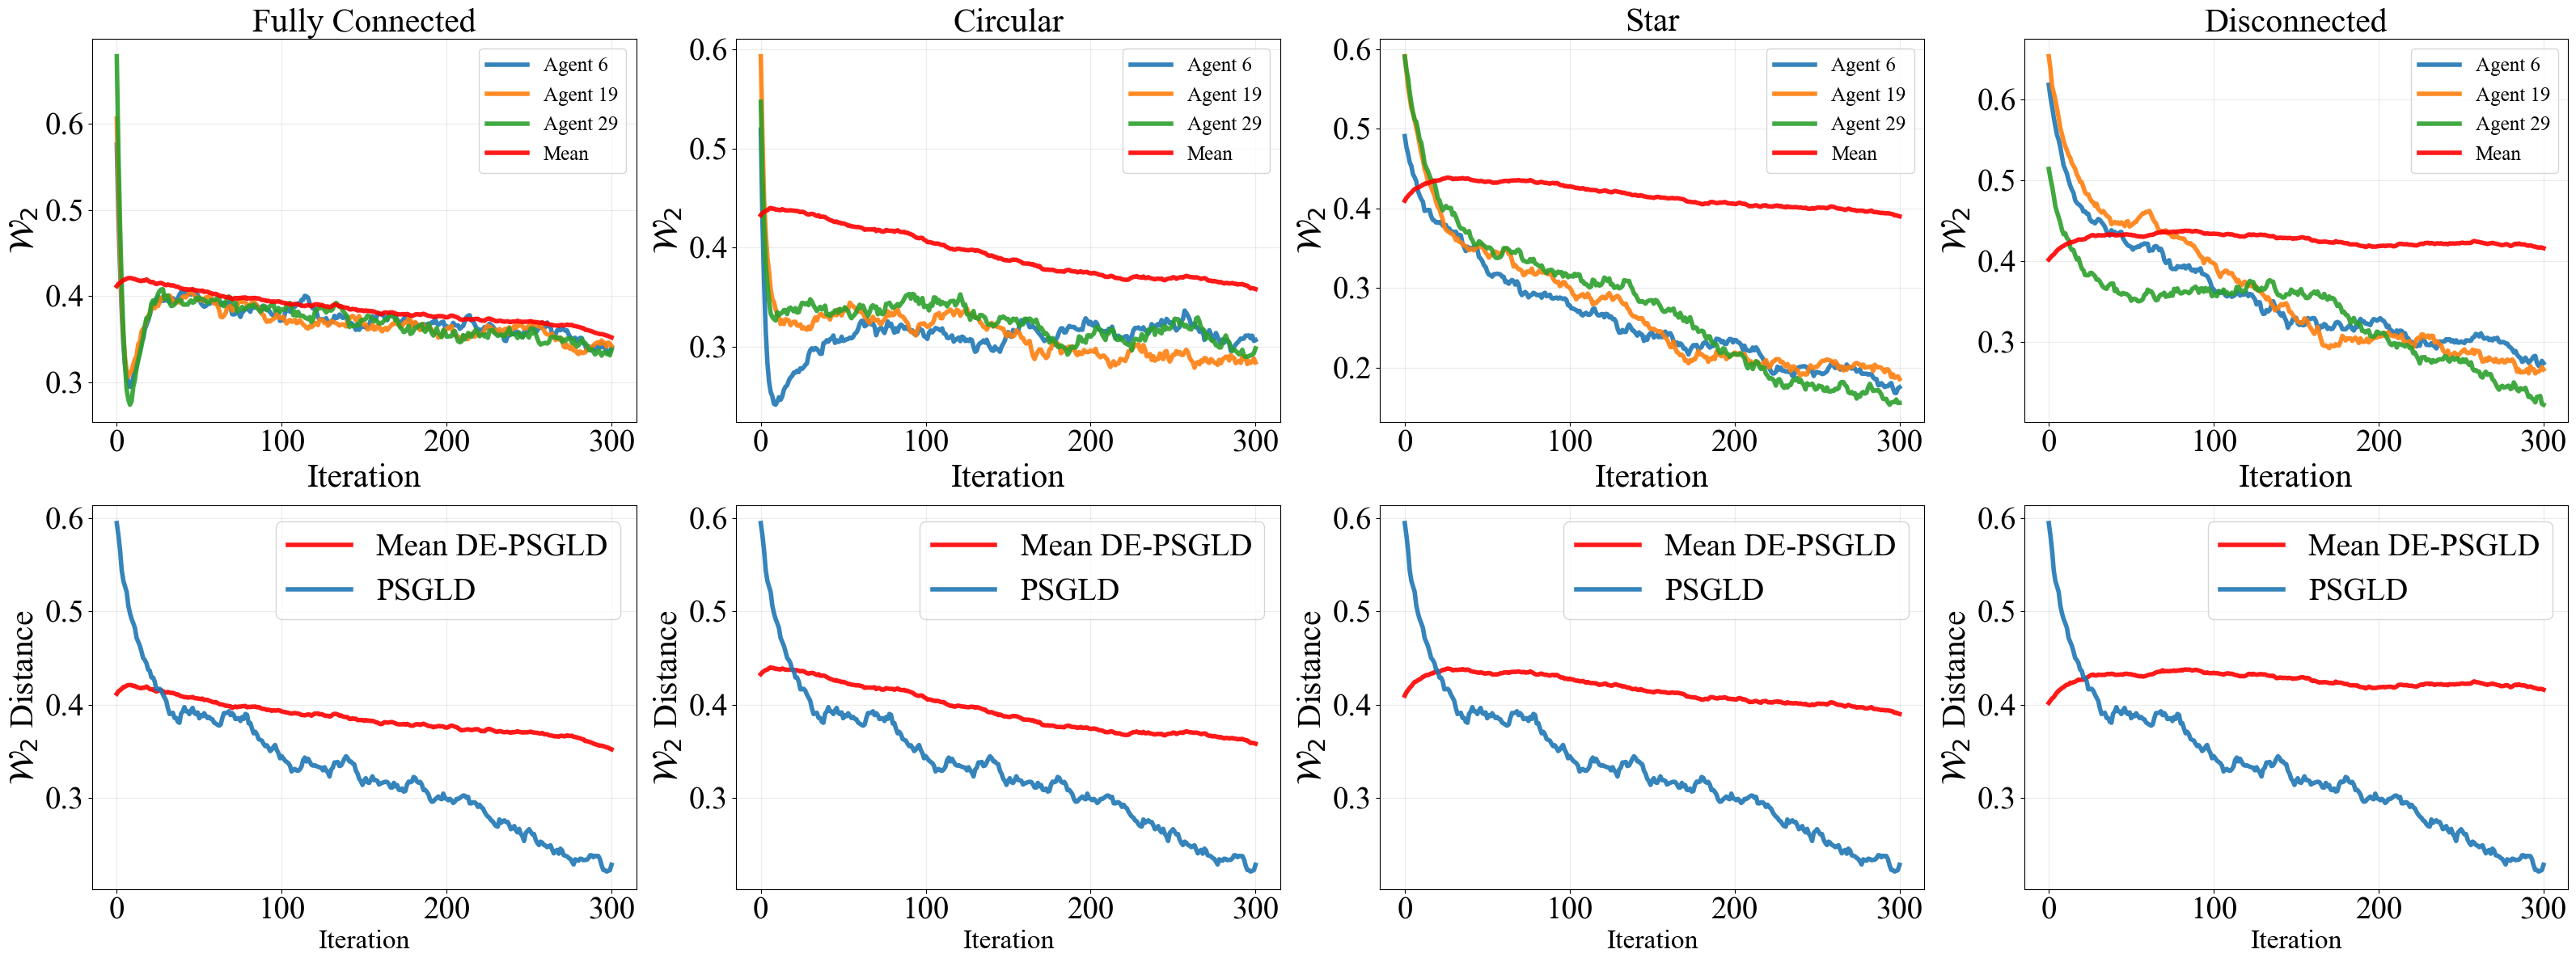

100%|██████████| 300/300 [00:00<00:00, 2860.30it/s]


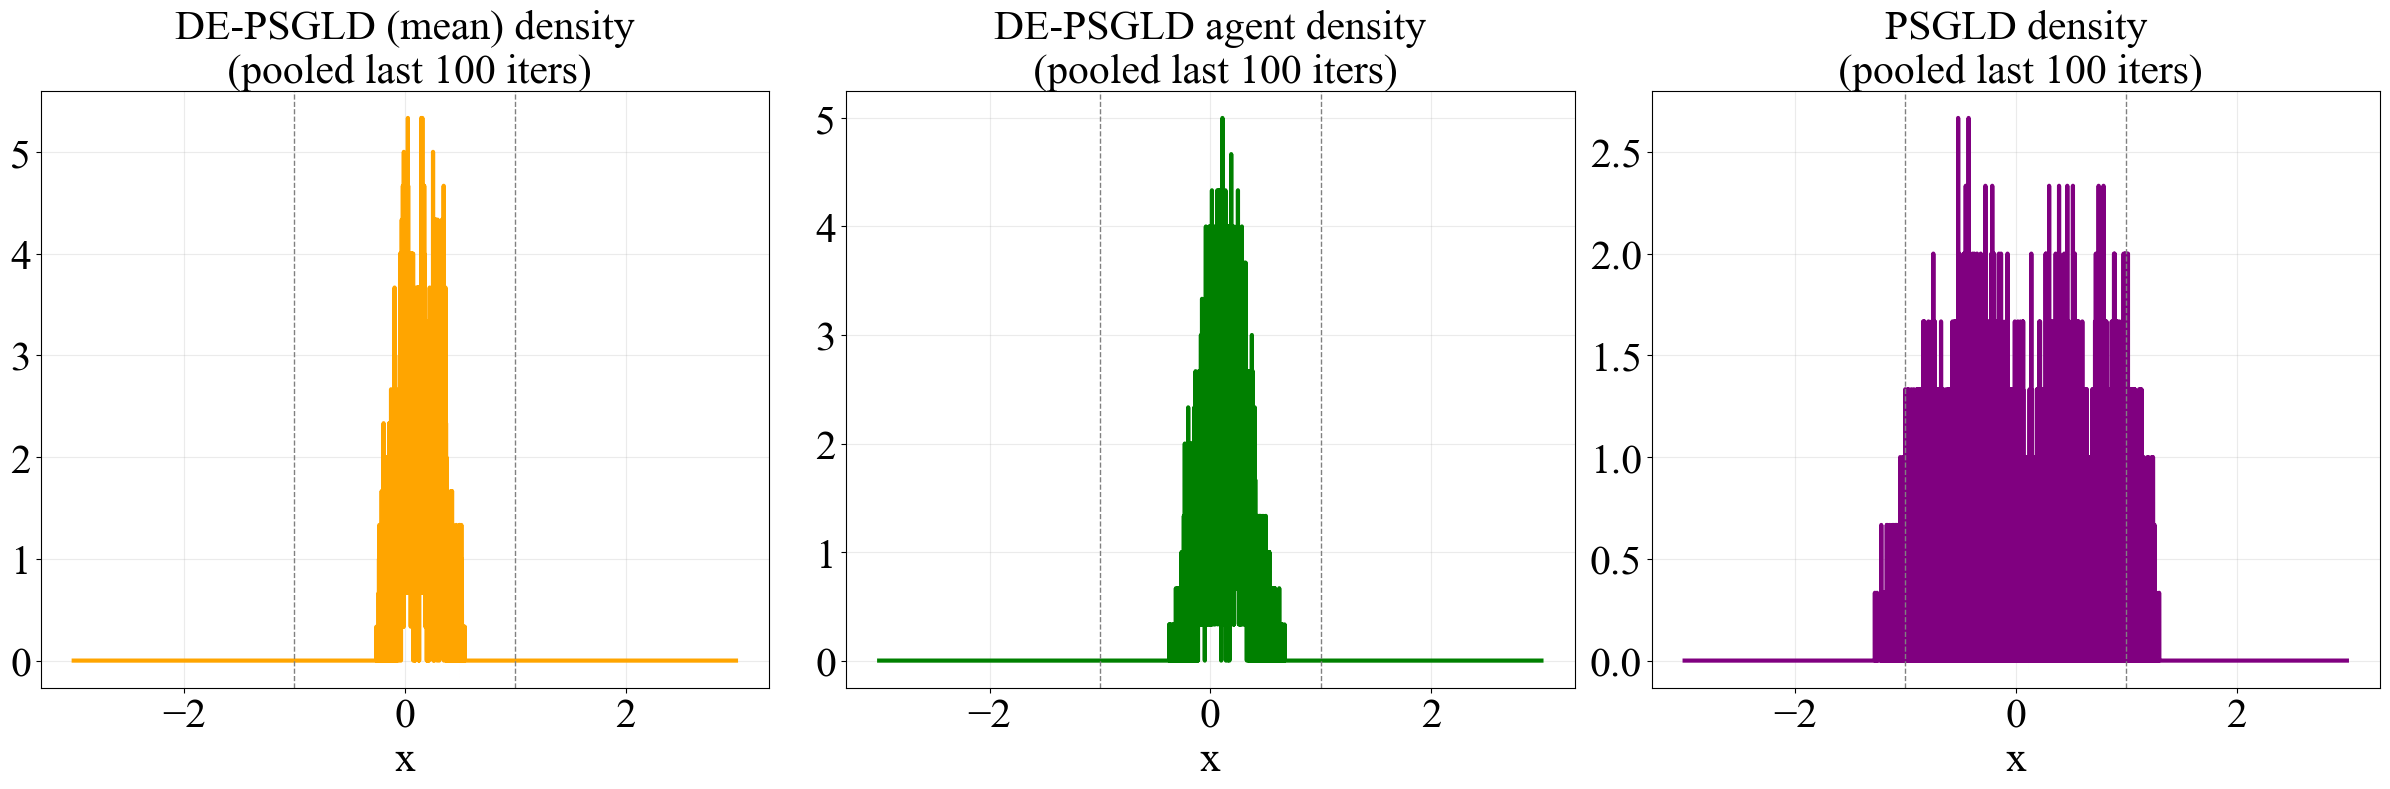

In [11]:
dpsgld_sampling_run(
    Q=Q, n_agents=30, n_samples=100, n_iters=300, eta=5e-4, gamma=1e-2,
    w2distplot=True, tail=100
    )